# Part 1 : Ядро Pytorch

PyTorch — это библиотека Python, которая облегчает создание проектов глубокого обучения. Она делает упор на гибкость и позволяет выражать модели глубокого обучения на идиоматическом Python.

Понимание глубокого обучения дает возможность решать задачи, которые ранее было невозможно автоматизировать. Эти навыки открывают новые карьерные возможности в разработке искусственного интеллекта (ИИ), и поскольку ИИ сейчас захватывает мир, PyTorch может стать вилкой и ножом. Хотя это обучение на PyTorch, концепции применимы к другим фреймворкам.

In [1]:
# импортируем pytorch
import torch

In [2]:
torch.version.__version__

'2.5.1+cu121'

In [3]:
# проверка подключения cuda
torch.cuda.is_available()

True

In [4]:
# системная версия python
!python --version

Python 3.13.5


In [5]:
# версия python в текущем окружении
import sys

In [6]:
sys.version

'3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]'

Отлично, система готова для работы!!!

In [7]:
# Импортируем реальные модели и взглянем на них
import torchvision
from torchvision import models

In [8]:
models.list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

Имена относятся к классам Python, которые реализуют ряд популярных моделей. Они отличаются своей архитектурой — то есть расположением операций, происходящих между входом и выходом. Имена с маленькой буквы являются удобными функциями, которые возвращают модели, созданные из этих классов, иногда с разными наборами параметров. Например, densenet121 возвращает экземпляр DenseNet с 121 слоем, densenet201 имеет 201 слой и так далее. Теперь мы обратим наше внимание на AlexNet.

## AlexNet

AlexNet остается историческим этапом для глубокого обучения. Он вновь возродил интерес к этой области и вывел её в мейнстрим. До появления AlexNet нейронные сети теряли популярность из-за ограниченных вычислительных ресурсов и посредственных результатов на задачах крупного масштаба. Однако в 2012 году архитектура AlexNet выиграла конкурс ILSVRC с большим отрывом, с ошибкой среди пяти лучших предсказаний (т.е. правильная метка должна быть в пяти лучших предсказаниях) на уровне 15,4%. Для сравнения, второе место, которое не использовало глубокую сеть, показало результат 26,2%. Это был определяющий момент в истории компьютерного зрения: момент, когда сообщество стало осознавать потенциал глубокого обучения для задач зрения. За этим скачком последовали постоянные улучшения с более современными архитектурами и методами обучения, достигая показателей ошибки в топ-5 всего 3%.

По современным стандартам, AlexNet — это довольно небольшая сеть по сравнению с современными передовыми моделями. Но в нашем случае она идеально подходит для того, чтобы впервые взглянуть на нейронную сеть, которая что-то делает, и научиться запускать её предварительно обученную версию на новом изображении. У нас ещё нет всех элементов для её понимания, но мы можем предугадать некоторые аспекты. Во-первых, каждый блок состоит из множества умножений и сложений, плюс немного других функций на выходе. Мы можем рассматривать её как фильтр — функцию, которая принимает одно или несколько изображений на вход и выдаёт другие изображения на выход. То, как это происходит, определяется во время обучения, на основе примеров, которые сеть видела, и желаемых результатов для них.

Входные изображения поступают слева и проходят через пять наборов фильтров, каждый из которых создаёт промежуточные представления изображений. После каждого фильтра эти представления уменьшаются в размере, как указано. Промежуточные представления, создаваемые последним набором фильтров, преобразуются в одномерный вектор из 4096 элементов и классифицируются для получения 1000 выходных вероятностей, по одной для каждого класса выхода.

Чтобы запустить архитектуру AlexNet на входном изображении, мы можем создать экземпляр класса AlexNet. Вот как это делается:

In [9]:
# alexnet = models.AlexNet()

На данном этапе alexnet является объектом, который может запускать архитектуру AlexNet. Нам пока не обязательно понимать детали этой архитектуры. На данный момент, alexnet — это просто непрозрачный объект, который можно вызывать как функцию. Предоставив alexnet некоторые данные входного размера (скоро мы увидим, какими должны быть эти данные), мы выполним прямой проход через сеть. То есть входные данные пройдут через первый набор нейронов, выходы которых будут переданы следующему набору нейронов, и так до окончательного выхода. Практически говоря, предполагая, что у нас есть входной объект правильного типа, мы можем выполнить прямой проход с помощью output = alexnet(input).

Но если мы сделаем это, мы будем пропускать данные через всю сеть, чтобы получить мусор! Это потому, что сеть не инициализирована: её веса, числа, с помощью которых входные данные складываются и умножаются, не были обучены на чём-либо — сама сеть представляет собой пустое (или, скорее, случайное) поле. Нам нужно либо обучить её с нуля, либо загрузить веса из предыдущего обучения, что мы и сделаем сейчас. Для этого вернёмся к модулю models. Названия с заглавной буквы соответствуют классам, которые реализуют популярные архитектуры для компьютерного зрения. Названия с маленькой буквы — функции, которые создают модели с предопределённым количеством слоёв и единиц и, опционально, загружают и устанавливают в них предварительно обученные веса. Заметьте, что использование одной из этих функций не является обязательным: они просто делают процесс создания модели с определённым количеством слоёв и единиц, соответствующим построению предварительно обученных сетей, более удобным.

### The Vision Transformer(визуальный трансформер)

В настоящее время визуальные трансформеры (ViT; https://arxiv.org/pdf/2010.11929) возглавляют многие задачи компьютерного зрения, демонстрируя передовые результаты. Механизмы самовнимания, могут улавливать сложные взаимосвязи внутри изображений, что используется для повышения точности классификации. ViT для классификации изображений показали значительно более низкие показатели ошибок на ImageNet по сравнению с AlexNet. Показатели ошибок в топ-5 могут быть такими низкими, как 5% (по сравнению с 15,3% у AlexNet) — на это ушло целых 9 лет! Используя функцию vit_b_16, мы теперь создадим экземпляр ViT для классификации изображений. Мы передадим аргумент, который укажет функции скачать веса ViT_B_16_Weights.IMAGENET1K_V1, обученные на наборе данных ImageNet, содержащем 1,2 миллиона изображений и 1 000 категорий:

In [10]:
vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

In [11]:
# выведем информацию о структуре сети
vit

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

Пока мы наблюдаем за ходом загрузки, мы можем на минуту оценить, что vit_b_16 имеет 88,6 миллиона параметров — это много параметров для автоматической оптимизации!

То, что мы видим здесь, — это модули, по одному на строку. Обратите внимание, что у них нет ничего общего с модулями Python: это отдельные операции, строительные блоки нейронной сети. Их также называют слоями в других фреймворках глубокого обучения. Модули могут быть вложенными: более крупные строительные блоки (например, Encoder) содержат подмодули (такие как повторяющийся EncoderBlock), которые, в свою очередь, содержат другие модули. Распечатанные сводки модели показывают эту иерархию через отступы; концептуально это дерево, где контейнерные модули группируют и упорядочивают своих дочерних модулей (например, Sequential), что облегчает понимание и доступ к частям сети.
Мы видим, что модуль EncoderBlock содержит тот механизм внимания, который мы упоминали ранее в этом разделе, а также другие модули. Вот анатомия типичной глубокой нейронной сети для компьютерного зрения: более или менее последовательная цепочка операций и нелинейных функций, заканчивающаяся слоем (fc), который выдаёт оценки для каждого из 1,000 выходных классов (out_features). Переменную vit можно вызвать как функцию, принимая на вход одно или несколько изображений и выдавая равное количество оценок для каждого из 1,000 классов ImageNet. Прежде чем мы сможем это сделать, нам нужно предварительно обработать входные изображения, чтобы они имели правильный размер и их значения (цвета) находились примерно в одном числовом диапазоне. Для этого модуль torchvision предоставляет трансформации, которые позволяют быстро определить конвейеры базовых функций предварительной обработки:

In [12]:
from torchvision import transforms

In [13]:
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

В этом случае мы определили функцию предварительной обработки, которая будет масштабировать входное изображение до 256 × 256, обрезать изображение до 224 × 224 вокруг центра, преобразовывать его в тензор (многомерный массив PyTorch; в данном случае, 3D-массив с каналами цвета, высотой и шириной) и нормализовать его RGB-компоненты так, чтобы они имели заданные средние значения и стандартные отклонения. Эти значения должны совпадать с теми, которые были представлены сети во время обучения, если мы хотим, чтобы сеть давала осмысленные ответы. Мы более подробно рассмотрим преобразования, когда перейдём к созданию собственных моделей распознавания изображений в разделе 7.1.3.

Теперь мы можем взять фотографию нашей любимой собаки (например, bobby.jpg из репозитория GitHub), предварительно обработать её и затем посмотреть, что наш модель думает об этом. Мы можем начать с загрузки изображения с локальной файловой системы с помощью Pillow (https://pillow.readthedocs.io/en/stable), модуля для обработки изображений в Python:

In [14]:
from PIL import Image

In [15]:
img = Image.open(r"C:\Users\Админ\Desktop\py\DataScince\NN\learning\data\лёва.jpg")

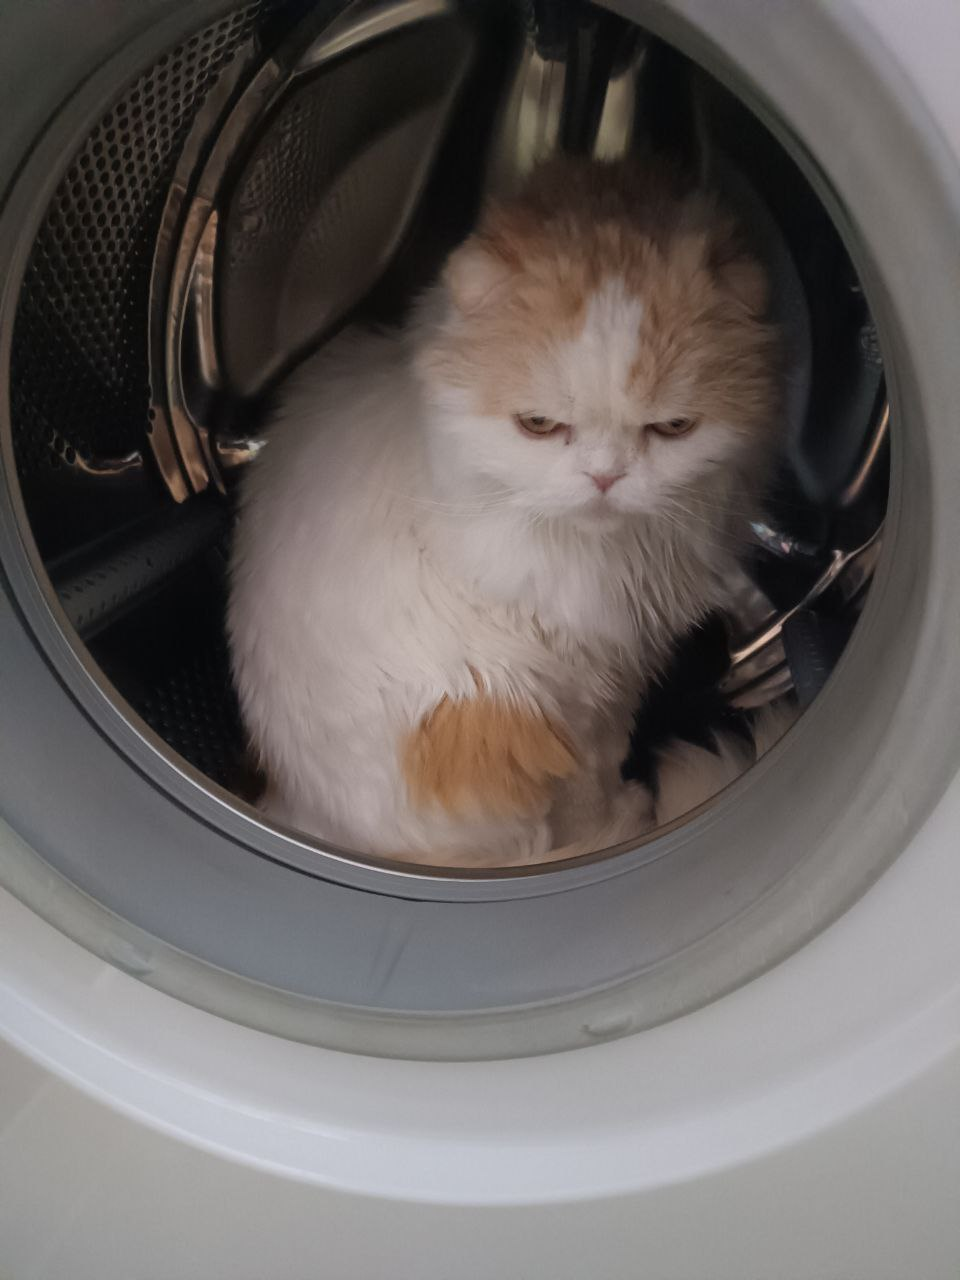

In [16]:
img

супер! все грузится))

Далее мы можем пропустить изображение через наш конвейер предварительной обработки:

In [17]:
img_t = preprocess(img)

Затем мы можем изменить форму, обрезать и нормализовать входной тензор так, как этого ожидает сеть. Мы больше поймем это далее в обучении пока держитесь:

In [18]:
batch_t = torch.unsqueeze(img_t, 0)

Теперь мы готовы запустить нашу модель!

### Run!!!

В области глубокого обучения термин, используемый для запуска обученной модели на новых данных, называется инференс. Чтобы выполнить инференс, нам нужно перевести сеть в режим eval:

In [19]:
vit.eval()

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

Если мы забудем это сделать, некоторые части модели, такие как пакетная нормализация и dropout, не будут давать осмысленные ответы просто из-за того, как они работают внутри. Теперь, когда режим eval установлен, мы готовы к инференсу:

In [20]:
out = vit(batch_t)
out

tensor([[ 7.9485e-01,  4.6823e-01,  5.5572e-02, -5.2429e-01,  2.1478e-01,
          5.5374e-01,  3.9680e-01,  4.0694e-01,  4.1713e-01, -2.5756e-01,
          3.7146e-01,  2.4789e-01,  1.3848e-02, -5.2242e-01,  1.7882e-01,
         -3.1950e-01, -1.9895e-01,  2.1143e-02, -1.4945e-02,  3.6882e-01,
          4.2419e-01,  3.5233e-01,  1.7244e-01, -1.4633e-01,  1.1124e-01,
          1.6012e-02, -2.0170e-01,  4.7315e-01, -1.4396e-02, -3.7115e-02,
         -1.4246e-01,  1.9923e-01,  2.9127e-01,  4.3350e-01, -1.8112e-01,
         -4.8720e-01,  1.2115e-01,  7.5187e-02,  2.3477e-01, -3.0910e-01,
         -5.6028e-01,  2.1305e-01, -5.4172e-01,  5.4878e-02, -5.1998e-01,
          2.1042e-01,  8.8165e-02,  9.0468e-02,  4.4216e-01,  7.7756e-01,
          4.8200e-01,  8.8947e-02, -8.6803e-02, -3.1416e-01, -6.0158e-01,
         -7.2519e-02, -6.0534e-01,  1.9974e-01,  8.7784e-01, -1.8745e-01,
          1.4482e-01, -1.7960e-01, -1.2782e-01, -6.4111e-01, -2.6111e-02,
         -1.3845e-02, -5.1835e-02,  6.

Только что произошло изумительное множество операций, включающее 88,6 миллиона параметров, в результате чего был получен вектор из 1 000 оценок — по одной на каждый класс ImageNet. Это не заняло много времени, правда? Теперь нам нужно узнать метку класса, который получил наивысшую оценку. Это покажет, что модель увидела на изображении. Если метка совпадает с тем, как человек описал бы изображение, это замечательно! Это значит, что всё работает. Если нет, значит, либо что-то пошло не так во время обучения, либо изображение настолько отличается от того, что ожидает модель, что модель не может правильно его обработать, либо возникла какая-то другая похожая проблема. Чтобы увидеть список предсказанных меток, мы загрузим текстовый файл с перечнем меток в том же порядке, в котором они были представлены сети во время обучения, а затем выберем метку с индексом, который дал наивысшую оценку от сети. Почти все модели для распознавания изображений имеют выходные данные в форме, подобной той, с которой мы собираемся работать.

Давайте загрузим файл, содержащий 1 000 меток для классов набора данных ImageNet:

In [21]:
with open(r"C:\Users\Админ\Desktop\py\DataScince\NN\learning\data\imagenet_classes.txt") as f:
    labels = [line.strip() for line in f.readlines()]

На этом этапе нам нужно определить индекс, соответствующий максимальному значению в тензоре out, который мы получили ранее. Мы можем сделать это с помощью функции max в PyTorch, которая выводит максимальное значение в тензоре, а также индексы, где это максимальное значение встречалось:

In [22]:
_, index = torch.max(out, 1)

Теперь мы можем использовать индекс для доступа к метке. Здесь индекс не является обычным числом Python, а представляет собой одномерный тензор с одним элементом (конкретно, tensor([207])), поэтому нам нужно получить фактическое числовое значение, чтобы использовать его в качестве индекса для нашего списка меток, используя .item(). Это работает только для тензоров с одним элементом и возвращает значение тензора в виде стандартного числа Python. Мы также используем torch.nn.functional.softmax (http://mng.bz/BYnq) для нормализации наших выходных данных к диапазону [0, 1] и деления на сумму. Это дает нам что-то вроде того, насколько уверена модель в своем предсказании. В данном случае модель на 96% уверена, что она знает, что наблюдает золотистого ретривера:

In [23]:
percentage = torch.nn.functional.softmax(out, dim=1)[0] * 100
labels[index.item()], percentage[index.item()].item()

('washer, automatic washer, washing machine', 87.65982055664062)

Поскольку модель выдала оценки, мы также можем узнать, какие были вторые, третьи и так далее показатели. Для этого мы можем использовать функцию сортировки, которая сортирует значения по возрастанию или убыванию, а также предоставляет индексы отсортированных значений в исходном массиве:

In [24]:
_, indices = torch.sort(out, descending=True)
[(labels[idx], percentage[idx].item()) for idx in indices[0][:5]]

[('washer, automatic washer, washing machine', 87.65982055664062),
 ('Persian cat', 1.3303741216659546),
 ('tiger cat', 0.24018354713916779),
 ('strainer', 0.12311248481273651),
 ('Siamese cat, Siamese', 0.08333107829093933)]